In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nbformat
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [85]:
# Load dataset — update filename if yours is different
df = pd.read_csv('../data/data.csv', encoding='ISO-8859-1')

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded successfully!
Shape: 541909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [86]:
# Column types and non-null counts
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [87]:
# Statistical summary for numeric columns
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [88]:
# Missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


In [89]:
# Duplicate rows
print(f'=== Duplicate Rows ===')
print(f'Total duplicates: {df.duplicated().sum()}')

=== Duplicate Rows ===
Total duplicates: 5268


In [90]:
# Make a copy to preserve the original
df_clean = df.copy()

# ── 4a. Remove duplicate rows ──
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Duplicates removed: {before - after}')

Duplicates removed: 5268


In [91]:
# ── 4b. Handle missing values ──

# Drop rows where CustomerID is missing (cannot identify the customer)
df_clean.dropna(subset=['CustomerID'], inplace=True)

# Fill missing Description with 'Unknown'
if 'Description' in df_clean.columns:
    df_clean['Description'].fillna('Unknown', inplace=True)

print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [92]:
# ── 4c. Fix data types ──

# Convert InvoiceDate to datetime
if 'InvoiceDate' in df_clean.columns:
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
    df_clean['Year']  = df_clean['InvoiceDate'].dt.year
    df_clean['Month'] = df_clean['InvoiceDate'].dt.month
    df_clean['Day']   = df_clean['InvoiceDate'].dt.day
    print('InvoiceDate converted to datetime ✅')

# Convert CustomerID to string (it's an ID, not a number)
if 'CustomerID' in df_clean.columns:
    df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
    print('CustomerID converted to string ✅')

df_clean.dtypes

InvoiceDate converted to datetime ✅
CustomerID converted to string ✅


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
Year                    int32
Month                   int32
Day                     int32
dtype: object

In [93]:
# ── 4d. Remove invalid rows ──

# Remove rows with negative Quantity or UnitPrice (cancelled/erroneous orders)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f'Rows after removing negatives: {len(df_clean)}')

Rows after removing negatives: 392692


In [94]:
# ── 4e. Handle outliers using IQR method ──

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df_filtered = df[(df[column] >= lower) & (df[column] <= upper)]
    print(f'{column}: removed {before - len(df_filtered)} outliers')
    return df_filtered

df_clean = remove_outliers_iqr(df_clean, 'Quantity')
df_clean = remove_outliers_iqr(df_clean, 'UnitPrice')

print(f'\nFinal clean dataset shape: {df_clean.shape}')

Quantity: removed 25616 outliers
UnitPrice: removed 33842 outliers

Final clean dataset shape: (333234, 11)


In [95]:
# ── 4f. Create TotalPrice column & Save cleaned data ──

df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.to_csv('../data/data_cleaned.csv', index=False)
print('✅ Cleaned dataset saved to ../data/data_cleaned.csv')
df_clean.head()

✅ Cleaned dataset saved to ../data/data_cleaned.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34


In [96]:
# ── 5a. Statistical Summary ──
print('=== Final Statistical Summary ===')
df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].describe().round(2)

=== Final Statistical Summary ===


,Quantity,UnitPrice,TotalPrice
count,333234.00,333234.00,333234.00
mean,7.55,2.19,12.90
std,6.78,1.55,13.21
min,1.00,0.00,0.00
25%,2.00,1.25,3.90
50%,6.00,1.65,10.14
75%,12.00,2.95,17.40
max,27.00,7.50,178.80


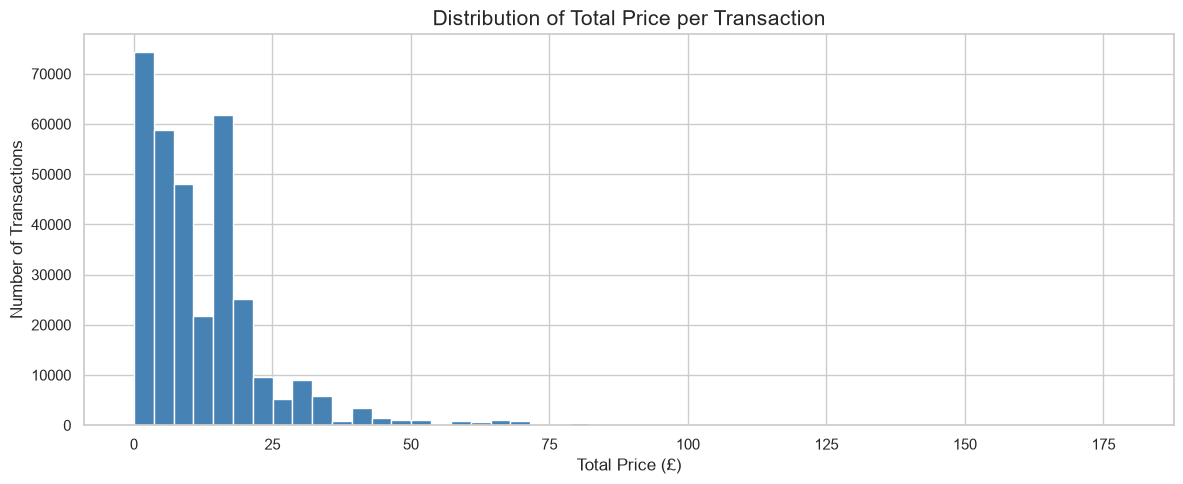

✅ Saved to reports/hist_totalprice.png


In [97]:
# ── 5b. Histogram — Distribution of TotalPrice ──
plt.figure(figsize=(12, 5))
plt.hist(df_clean['TotalPrice'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Total Price per Transaction', fontsize=15)
plt.xlabel('Total Price (£)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig('../reports/hist_totalprice.png', dpi=150)
plt.show()
print('✅ Saved to reports/hist_totalprice.png')

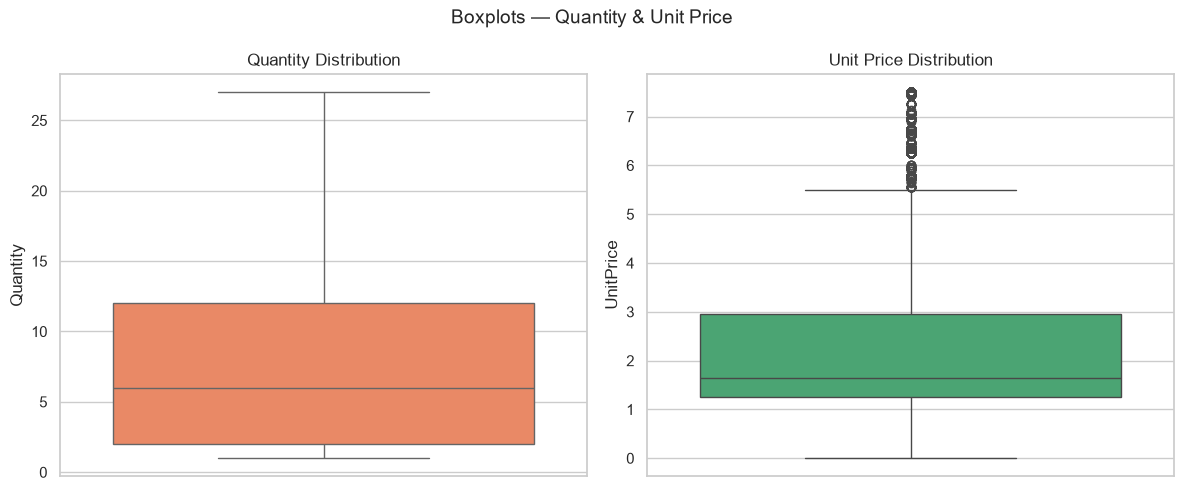

In [98]:
# ── 5c. Boxplot — Quantity and UnitPrice ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_clean['Quantity'], ax=axes[0], color='coral')
axes[0].set_title('Quantity Distribution')

sns.boxplot(y=df_clean['UnitPrice'], ax=axes[1], color='mediumseagreen')
axes[1].set_title('Unit Price Distribution')

plt.suptitle('Boxplots — Quantity & Unit Price', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/boxplot_quantity_price.png', dpi=150)
plt.show()

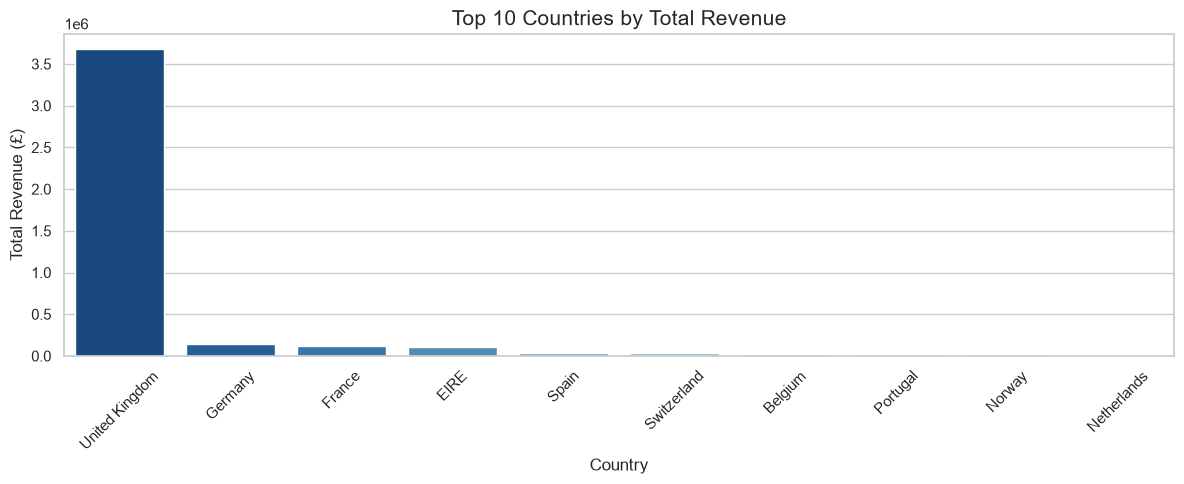

In [99]:
# ── 5d. Bar Chart — Top 10 Countries by Revenue ──
top_countries = (
    df_clean.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x='Country', y='TotalPrice', palette='Blues_r')
plt.title('Top 10 Countries by Total Revenue', fontsize=15)
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/bar_top_countries.png', dpi=150)
plt.show()

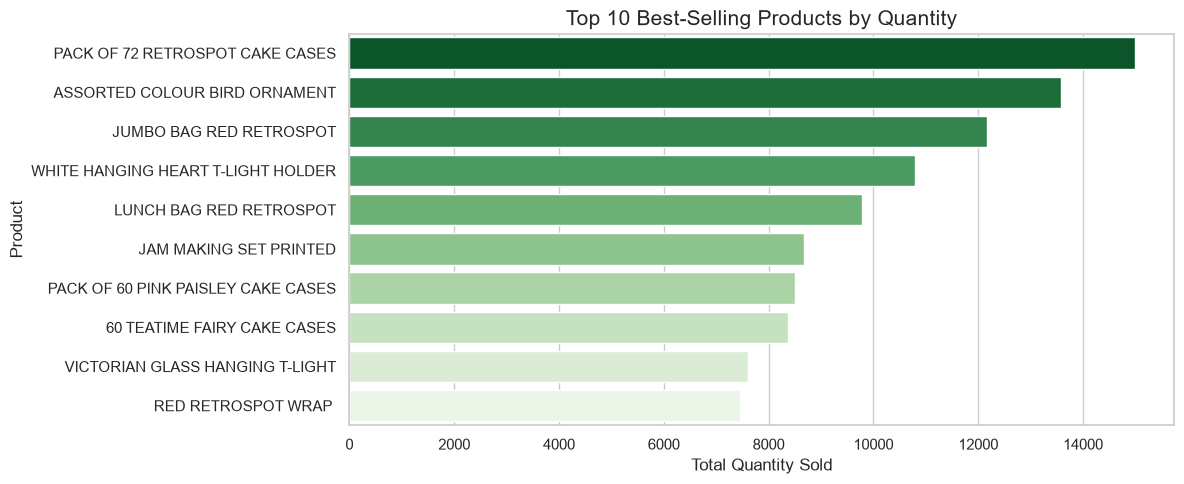

In [100]:
# ── 5e. Bar Chart — Top 10 Best-Selling Products ──
top_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x='Quantity', y='Description', palette='Greens_r')
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=15)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../reports/bar_top_products.png', dpi=150)
plt.show()

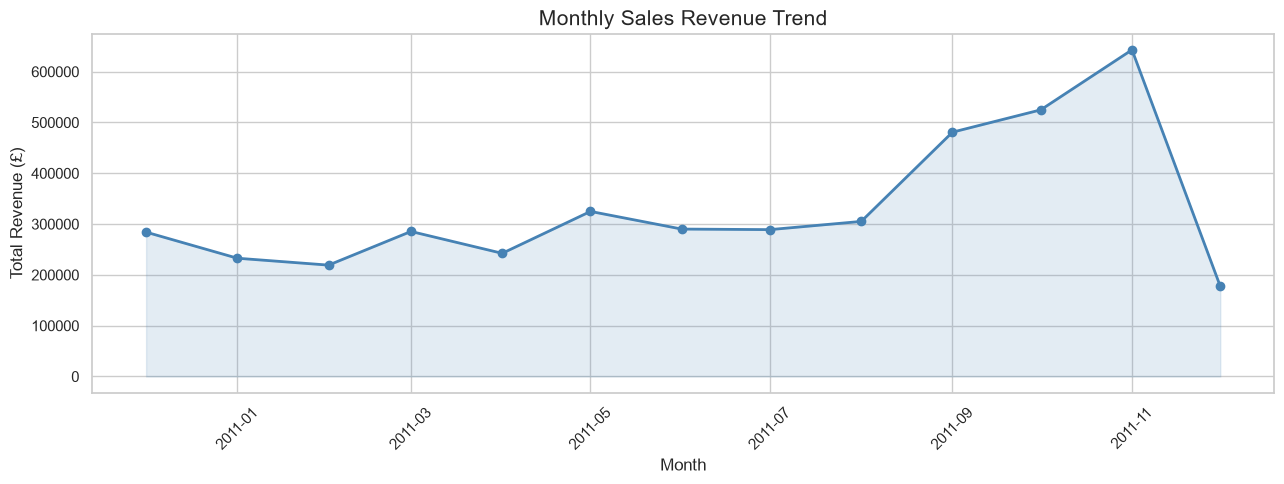

In [101]:
# ── 5f. Line Chart — Monthly Sales Trend ──
monthly_sales = (
    df_clean.groupby(['Year', 'Month'])['TotalPrice']
    .sum()
    .reset_index()
)
monthly_sales['Period'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
)
monthly_sales.sort_values('Period', inplace=True)

plt.figure(figsize=(13, 5))
plt.plot(monthly_sales['Period'], monthly_sales['TotalPrice'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly_sales['Period'], monthly_sales['TotalPrice'],
                 alpha=0.15, color='steelblue')
plt.title('Monthly Sales Revenue Trend', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/line_monthly_sales.png', dpi=150)
plt.show()

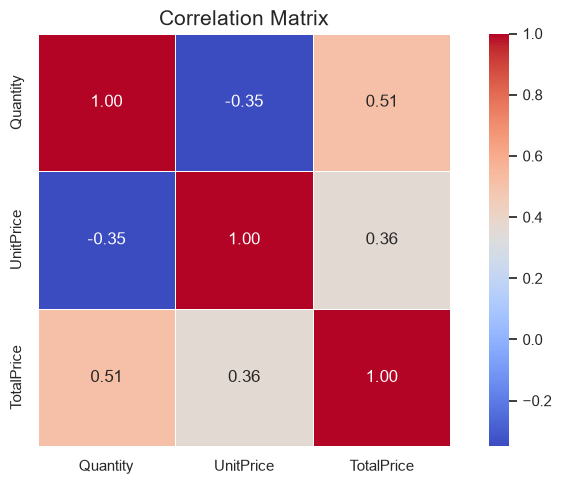

In [102]:
# ── 5g. Heatmap — Correlation Matrix ──
plt.figure(figsize=(8, 5))
corr = df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.savefig('../reports/heatmap_correlation.png', dpi=150)
plt.show()

In [103]:
# ── 5h. Interactive Chart (Plotly) — Monthly Sales ──
fig = px.line(
    monthly_sales, x='Period', y='TotalPrice',
    title='Interactive Monthly Sales Trend',
    labels={'TotalPrice': 'Revenue (£)', 'Period': 'Month'},
    markers=True
)
fig.write_html('../reports/interactive_monthly_sales.html')
print('✅ Interactive chart saved to reports/interactive_monthly_sales.html')

✅ Interactive chart saved to reports/interactive_monthly_sales.html


In [104]:
print('=' * 60)
print('           📌 5 KEY INSIGHTS FROM EDA')
print('=' * 60)

# Insight 1 — Top Country
top_country = top_countries.iloc[0]
print(f"""
1️⃣  TOP MARKET:
   '{top_country['Country']}' is the highest revenue-generating
   country with £{top_country['TotalPrice']:,.0f} in total sales.
""")

# Insight 2 — Best Product
top_product = top_products.iloc[0]
print(f"""
2️⃣  BEST-SELLING PRODUCT:
   '{top_product['Description']}' is the most purchased product
   with {top_product['Quantity']:,} units sold.
""")

# Insight 3 — Peak Month
peak_month = monthly_sales.loc[monthly_sales['TotalPrice'].idxmax()]
print(f"""
3️⃣  PEAK SALES MONTH:
   {peak_month['Period'].strftime('%B %Y')} recorded the highest revenue
   of £{peak_month['TotalPrice']:,.0f}.
""")

# Insight 4 — Average Order Value
avg_order = df_clean['TotalPrice'].mean()
print(f"""
4️⃣  AVERAGE ORDER VALUE:
   The average transaction value is £{avg_order:.2f},
   suggesting most purchases are small-to-mid range.
""")

# Insight 5 — Unique Customers
unique_customers = df_clean['CustomerID'].nunique()
unique_products  = df_clean['Description'].nunique()
print(f"""
5️⃣  CUSTOMER & PRODUCT DIVERSITY:
   The dataset contains {unique_customers:,} unique customers
   purchasing across {unique_products:,} different products,
   showing a diverse customer base.
""")

print('=' * 60)

           📌 5 KEY INSIGHTS FROM EDA

1️⃣  TOP MARKET:
   'United Kingdom' is the highest revenue-generating
   country with £3,680,989 in total sales.


2️⃣  BEST-SELLING PRODUCT:
   'PACK OF 72 RETROSPOT CAKE CASES' is the most purchased product
   with 14,986 units sold.


3️⃣  PEAK SALES MONTH:
   November 2011 recorded the highest revenue
   of £642,985.


4️⃣  AVERAGE ORDER VALUE:
   The average transaction value is £12.90,
   suggesting most purchases are small-to-mid range.


5️⃣  CUSTOMER & PRODUCT DIVERSITY:
   The dataset contains 4,191 unique customers
   purchasing across 3,575 different products,
   showing a diverse customer base.

